In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick


ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [30]:
bvals = np.linspace(10, 2000, 100)
bvecs = jax.random.normal(jax.random.PRNGKey(0), shape=(100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.jit
def simulator(rng):
    theta = jax.random.normal(rng, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng, p=0.5, shape=(3,))
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    return model_mask, theta, x_o
    

In [31]:
from dmri.nn.tokenizer import StructuredTokenizer
from dmri.nn.autoregressive import ModelIdentificationDecoder
from flax import nnx

#tokenizer = StructuredTokenizer(dims_per_component, rngs=nnx.Rngs(0))
model = ModelIdentificationDecoder(rngs=nnx.Rngs(0), context_dim=100, num_layers=2, widening_factor=4)
params = nnx.state(model, nnx.Param)

In [32]:
masks, thetas, x_os = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(1), 10))

model(masks, context=x_os)

Array([[ 0.556,  0.17 ,  1.19 ],
       [ 0.   ,  0.787,  0.534],
       [ 0.   ,  0.787,  0.534],
       [ 0.   ,  0.787,  0.534],
       [ 0.338,  0.585, -0.433],
       [ 1.303,  0.449,  1.332],
       [ 0.647,  0.196,  1.233],
       [ 1.123,  0.539,  0.502],
       [ 0.   ,  0.787,  0.534],
       [ 0.292,  0.19 ,  1.11 ]], dtype=float32)

In [33]:
model(masks, context=x_os)

Array([[ 0.556,  0.17 ,  1.19 ],
       [ 0.   ,  0.787,  0.534],
       [ 0.   ,  0.787,  0.534],
       [ 0.   ,  0.787,  0.534],
       [ 0.338,  0.585, -0.433],
       [ 1.303,  0.449,  1.332],
       [ 0.647,  0.196,  1.233],
       [ 1.123,  0.539,  0.502],
       [ 0.   ,  0.787,  0.534],
       [ 0.292,  0.19 ,  1.11 ]], dtype=float32)

In [34]:
import optax

optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(1e-3))

opt_state = optimizer.init(params)


def loss_fn(params, data, rng):
    nnx.update(model, params)
    components, thetas, xs = data

    logits = model(components, context=xs)

    loss =  optax.sigmoid_binary_cross_entropy(logits, components).sum(-1).mean()

    return loss

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [35]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [36]:
%%timeit
batch_simulator(jax.random.split(jax.random.PRNGKey(1), 2**12))

376 ms ± 21.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
key = jax.random.PRNGKey(1)
for i in range(50):
    key, subkey1 = jax.random.split(key, 2) 
    masks, thetas, x_os = batch_simulator(jax.random.split(subkey1, 2**15))
    l = 0
    for j in range(100):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (128,), 0, 2048)
        masks_batch, thetas_batch, x_os_batch = masks[idx], thetas[idx], x_os[idx]
        params, opt_state, loss = update(params, opt_state, (masks_batch, thetas_batch, x_os_batch), subkey2)
        l += loss
    print(l/100) 

0.7404142
0.7391072
0.7103665
0.6995082
0.7329873
0.7218715
0.71292883
0.7401635
0.71343887
0.73234266
0.73936313
0.71418244
0.7162087
0.67619365
0.6848924
0.7124806
0.7054079
0.6730667
0.6742856
0.66004735
0.7160991
0.69524014
0.6566587
0.685079
0.7373295
0.6863026
0.70984596
0.630632
0.6730214
0.64160216
0.660779
0.66605073
0.66573995
0.65115535
0.65190184
0.69047165
0.6657402
0.69187814
0.64903927
0.6611792
0.6584564
0.6473732
0.6408165
0.6460638
0.6497843
0.6329301
0.63295406
0.66968197
0.69455856
0.6439493


In [44]:
nnx.update(model, params)

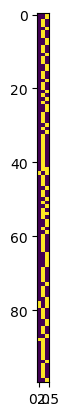

In [46]:
samples = jax.vmap(lambda k: model.sample(k, x_os[2],3))(jax.random.split(jax.random.PRNGKey(0), 100))
plt.imshow(samples)